In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns #type: ignore
import os
import json

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import pickle
from datetime import datetime
import warnings
import traceback
import sys

import xgboost as xgb #type: ignore
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from datetime import timedelta

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from helpFolder import *

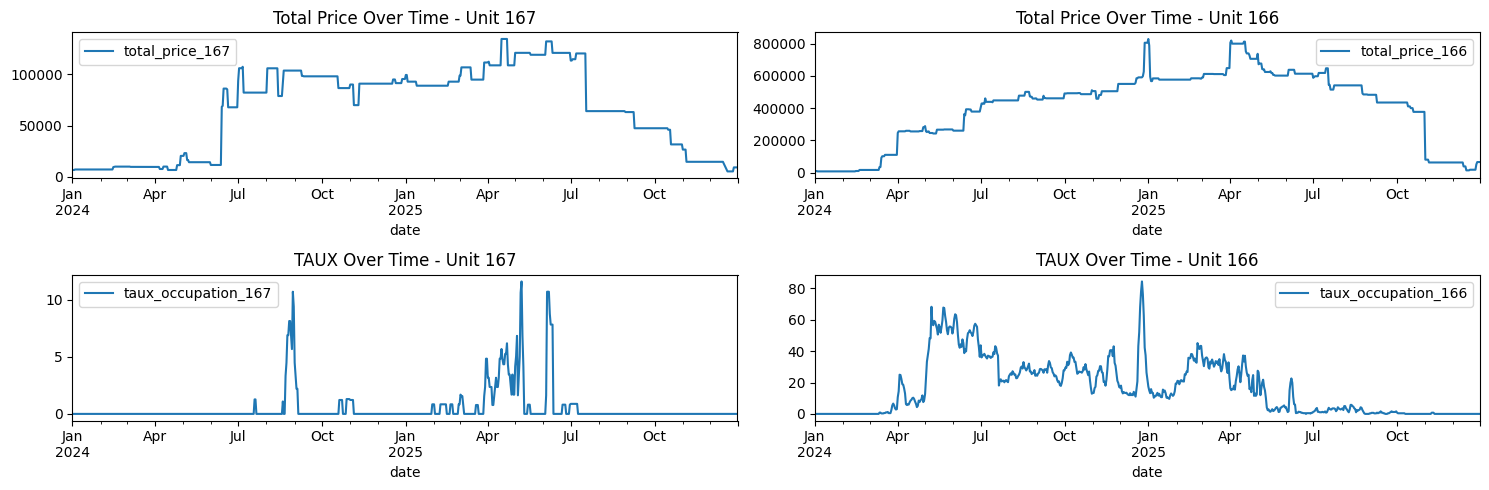

In [2]:
df_167, df_166 = prepare_and_plot_data('../../Data/UnitsFinalCSVData/FinalCSVdata.csv', 
                                       '2024-06-15', '2025-07-15')

### Train the models to take the price and return the taux : **Linear Regression**

--- Starting Linear Regression Pipeline for Unit 166 ---
Target type: taux (predicting occupancy rate)

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: taux_occupation_166
Training set range: 2024-06-15 00:00:00 to 2025-04-26 00:00:00 (316 samples)
Testing set range: 2025-04-27 00:00:00 to 2025-07-15 00:00:00 (80 samples)

[Step 2/3] Training and evaluating Linear Regression model...

Training Linear Regression model for target: taux_occupation_166
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Training set size: 316 samples
Testing set size: 80 samples

Model Evaluation Metrics:
Train RMSE: 11.19
Test RMSE: 17.35
Train MAE: 8.74
Test MAE: 16.18
Train R²: 0.0876
Test R²: -5.1398

Feature Importance (Coefficients):
           Feature  Coefficient
2             year   -12.529396
1            month    -6.986709
0        dayofweek    -0.247154
3        dayofyear     0.174169
4       weekofyear  

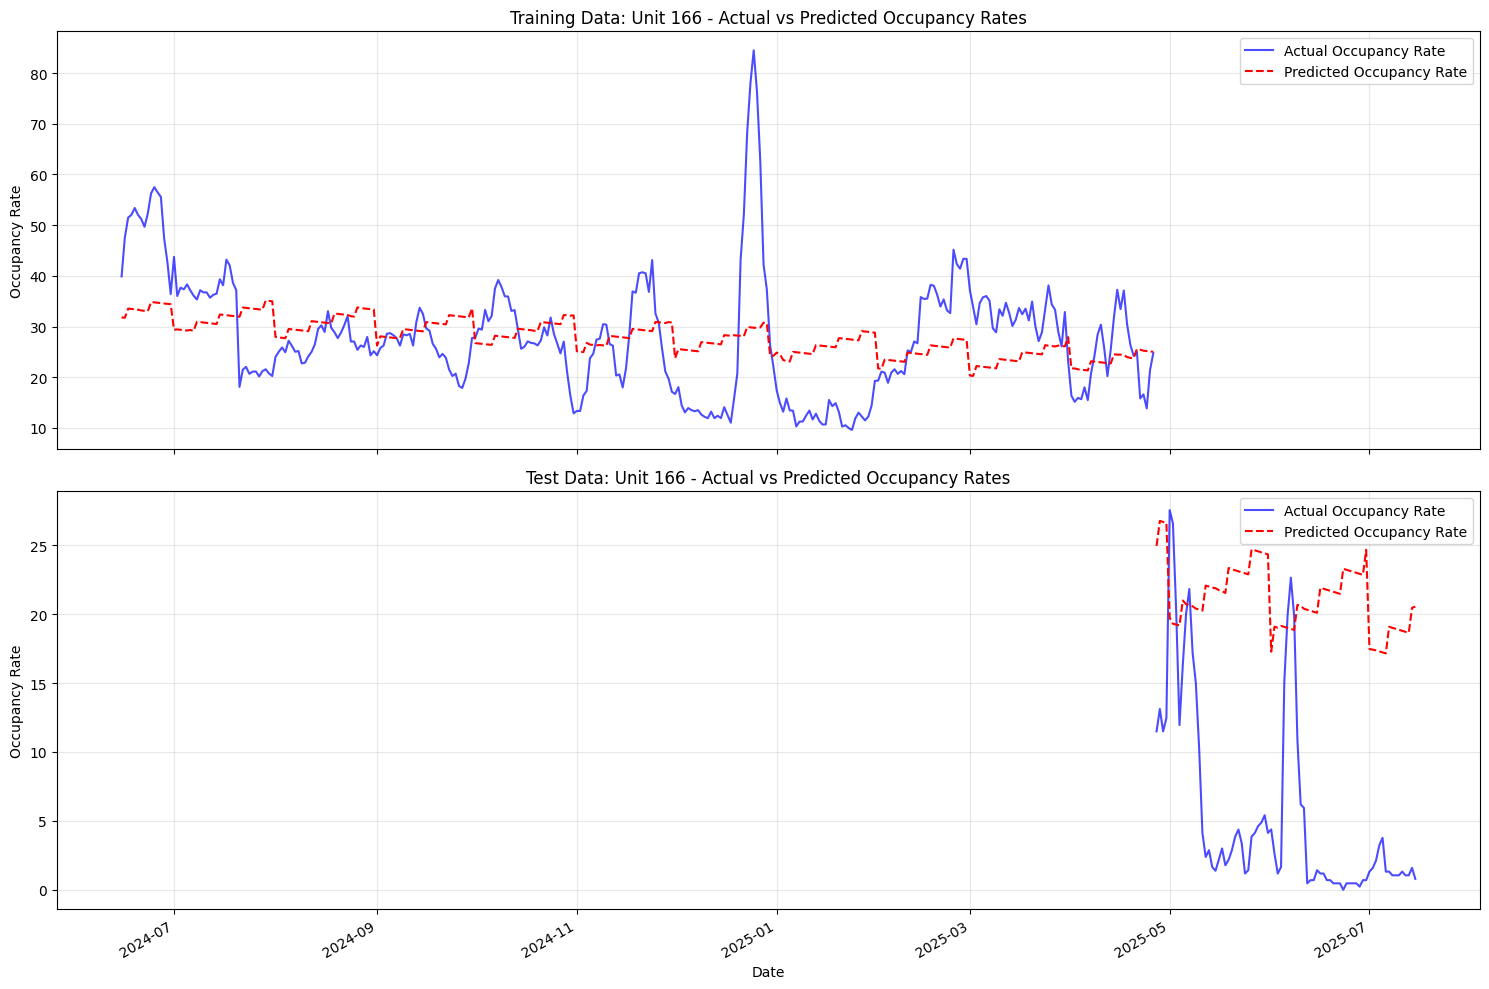

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Target column: taux_occupation_166


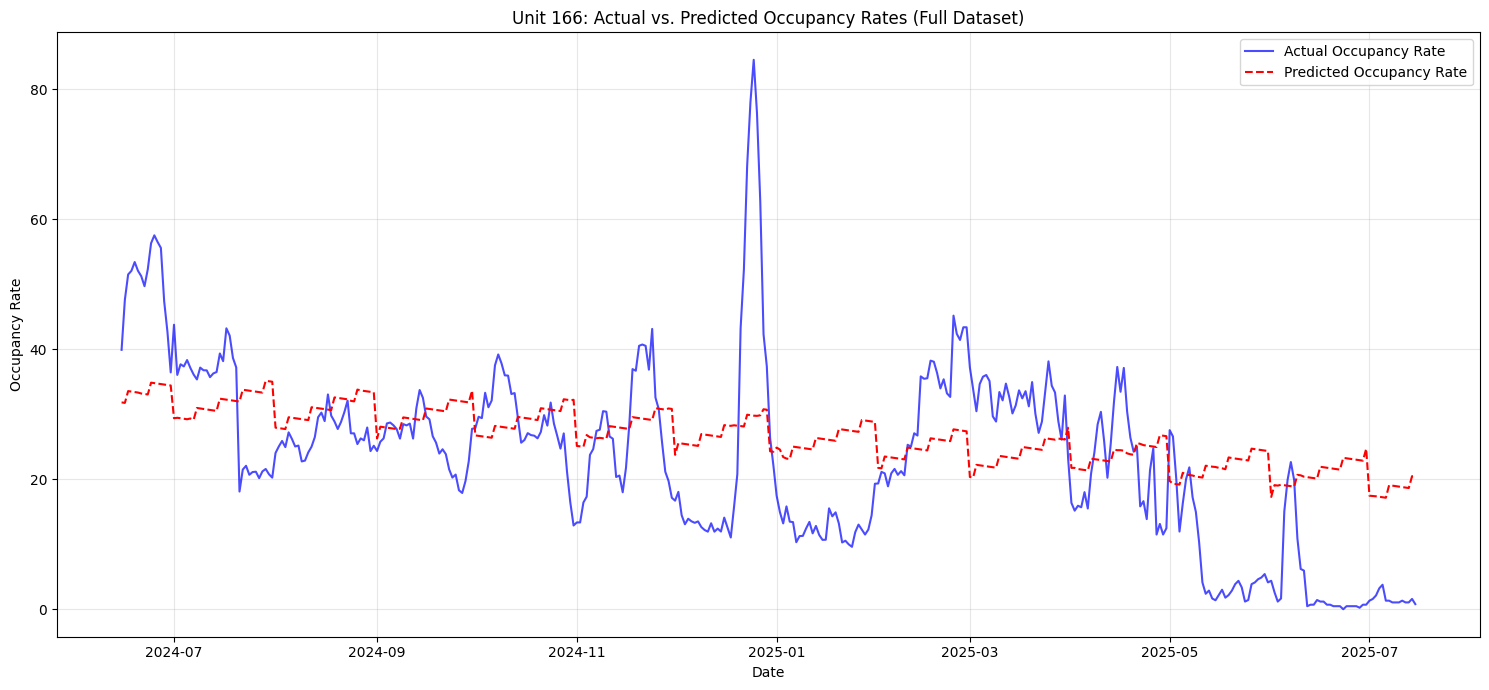


Pipeline finished for Unit 166.
--- End Linear Regression Pipeline ---
--- Starting Linear Regression Pipeline for Unit 167 ---
Target type: taux (predicting occupancy rate)

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: taux_occupation_167
Training set range: 2024-06-15 00:00:00 to 2025-04-26 00:00:00 (316 samples)
Testing set range: 2025-04-27 00:00:00 to 2025-07-15 00:00:00 (80 samples)

[Step 2/3] Training and evaluating Linear Regression model...

Training Linear Regression model for target: taux_occupation_167
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_167']
Training set size: 316 samples
Testing set size: 80 samples

Model Evaluation Metrics:
Train RMSE: 1.36
Test RMSE: 3.27
Train MAE: 0.95
Test MAE: 2.77
Train R²: 0.3396
Test R²: -0.0595

Feature Importance (Coefficients):
           Feature  Coefficient
1            month    -1.610053
2             year    -0.638818
3        dayofy

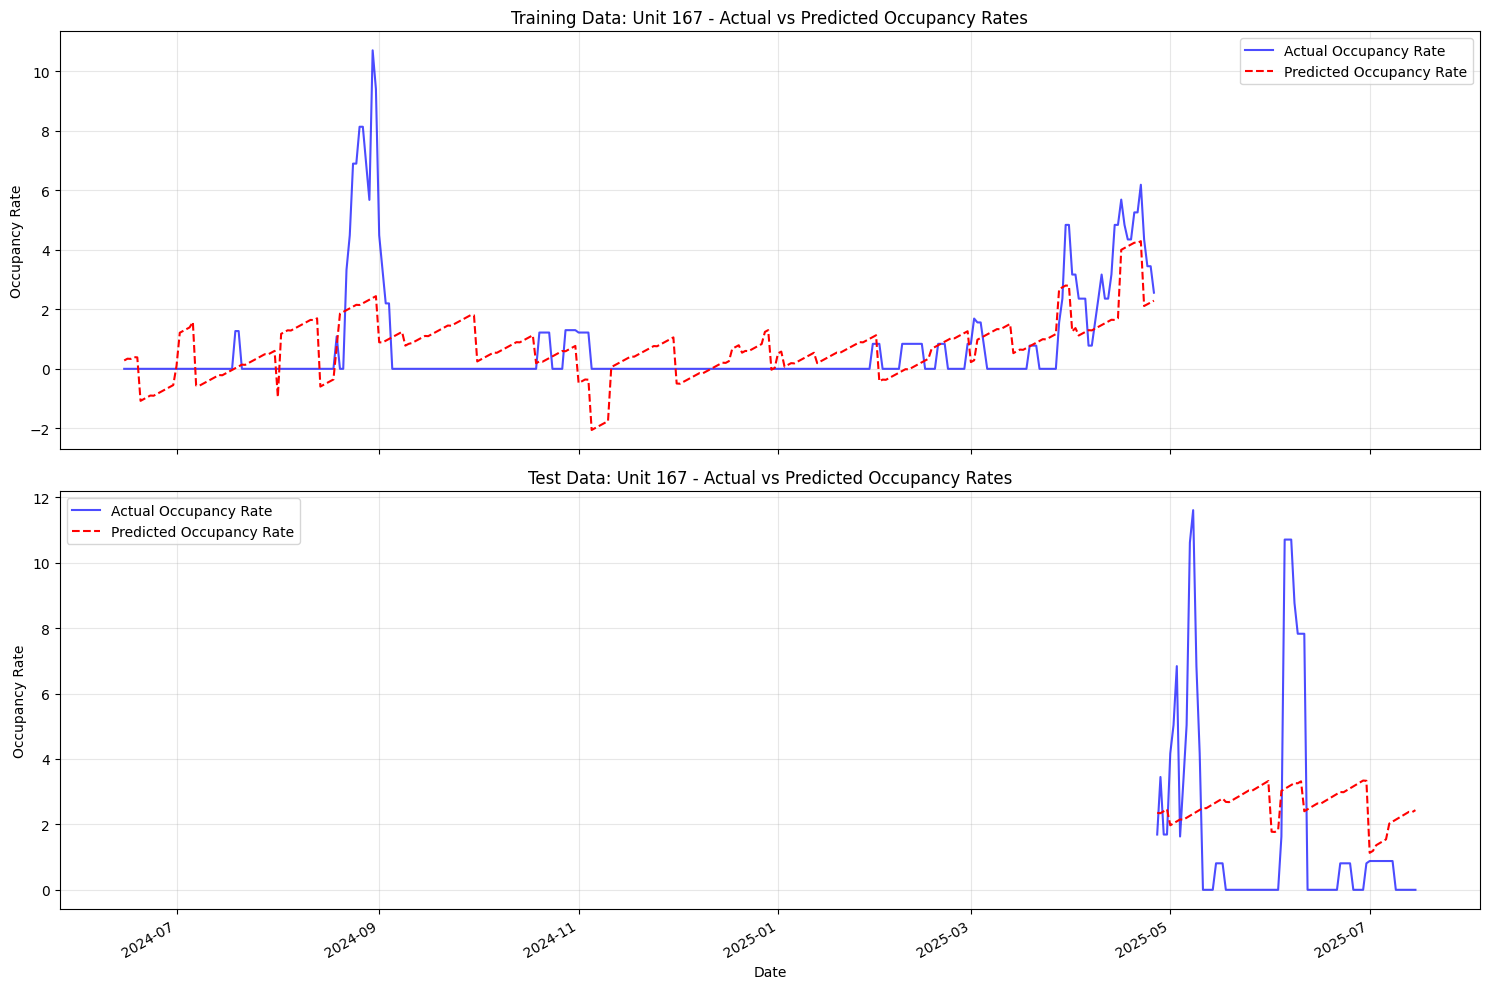

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_167']
Target column: taux_occupation_167


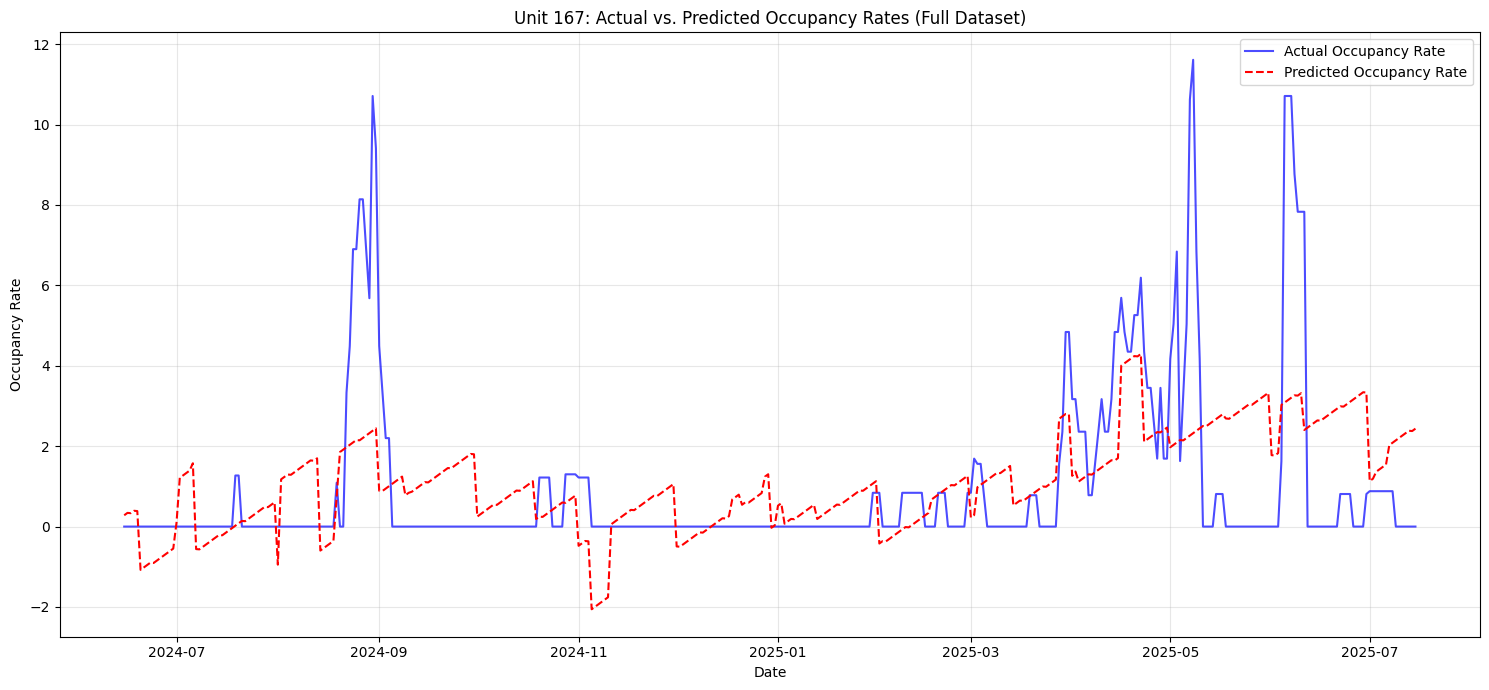


Pipeline finished for Unit 167.
--- End Linear Regression Pipeline ---


In [6]:
results_rl_taux_166 = run_linear_regression_pipeline(df_166, unit_id='166', target_type='taux')
results_rl_taux_167 = run_linear_regression_pipeline(df_167, unit_id='167', target_type='taux')

In [7]:
path_save = '../TrainedModels/UnitsBasedModels/PredictTaux/LinearRegression'
save_lr_model(results_rl_taux_166, path_save, 'linear_regression_model_166')
save_lr_model(results_rl_taux_167, path_save, 'linear_regression_model_167')

Model successfully saved to ../TrainedModels/UnitsBasedModels/PredictTaux/LinearRegression\linear_regression_model_166.pkl
Model successfully saved to ../TrainedModels/UnitsBasedModels/PredictTaux/LinearRegression\linear_regression_model_167.pkl


'../TrainedModels/UnitsBasedModels/PredictTaux/LinearRegression\\linear_regression_model_167.pkl'

In [21]:
path_save = '../TrainedModels/UnitsBasedModels/PredictTaux/LinearRegression'
lr_model_166_taux = load_rl_model(path_save, 'linear_regression_model_166')
lr_model_167_taux = load_rl_model(path_save, 'linear_regression_model_167')

Model successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LinearRegression\linear_regression_model_166.pkl
Model successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LinearRegression\linear_regression_model_167.pkl


In [22]:
path_save = '../TrainedModels/UnitsBasedModels/PredictPrice/LinearRegression'
lr_model_166_price = load_rl_model(path_save, 'linear_model_166')
lr_model_167_price = load_rl_model(path_save, 'linear_model_167')

Model successfully loaded from ../TrainedModels/UnitsBasedModels/PredictPrice/LinearRegression\linear_model_166.pkl
Model successfully loaded from ../TrainedModels/UnitsBasedModels/PredictPrice/LinearRegression\linear_model_167.pkl


In [23]:
predicted_taux = predict_single_date_linear_model(lr_model_166_taux, '2025-04-23', '166', 705606.1370000014, target_type='taux')
predicted_taux


Predicting taux_occupation_166 for Unit 166 on 2025-04-23 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      4  2025        113          17       705606.137


25.23688623853377

In [26]:
predicted_price = predict_single_date_linear_model(lr_model_166_price, '2025-04-23', '166', 50.23688623853377, target_type='price')
predicted_price


Predicting total_price_166 for Unit 166 on 2025-04-23 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      4  2025        113          17            50.236886


685625.3993512392

In [ ]:
best_price, max_taux = find_max_price_for_date_linear_model(
    model=lr_model_166_taux, 
    target_date_str='2025-04-15', 
    unit_id='166',
    min_value=50000.0,
    max_value=800000.0,
    step=1000.0,
    target_type='taux'
)

print(f"\nBest price for unit 166 on 2025-04-15: {best_price}, Max taux: {max_taux}")


Searching for optimal price for unit 166 on 2025-04-15
Range: 50000.00-800000.00, step: 1000.0
Target: maximize predicted taux_occupation


Testing price values:   8%|▊         | 60/751 [00:00<00:02, 299.25it/s]


Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16          50000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16          51000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16          52000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16          53000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105

Testing price values:  12%|█▏        | 92/751 [00:00<00:02, 304.54it/s]


Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16         110000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16         111000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16         112000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16         113000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105

...


Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16         600000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16         601000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16         602000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16         603000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105

Testing price values:  99%|█████████▉| 743/751 [00:02<00:00, 309.10it/s]


Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16         694000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16         695000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16         696000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16         697000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105

Testing price values: 100%|██████████| 751/751 [00:02<00:00, 305.28it/s]


Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16         793000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16         794000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16         795000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105          16         796000.0

Predicting taux_occupation_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          1      4  2025        105

In [30]:
best_taux, max_price = find_max_price_for_date_linear_model(
    model=lr_model_166_price, 
    target_date_str='2025-04-15', 
    unit_id='166',
    min_value=0.0,
    max_value=90.0,
    step=1,
    target_type='price'
)

print(f"\nBest taux for unit 166 on 2025-04-15: {best_taux}, Max price: {max_price}")


Searching for optimal taux_occupation for unit 166 on 2025-04-15
Range: 0.00-90.00, step: 1
Target: maximize predicted price


Testing taux_occupation values:  27%|██▋       | 25/91 [00:00<00:00, 242.69it/s]


Predicting total_price_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          1      4  2025        105          16                  0.0

Predicting total_price_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          1      4  2025        105          16                  1.0

Predicting total_price_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          1      4  2025        105          16                  2.0

Predicting total_price_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          1      4  2025        105          16                  3.0

Predicting total_price_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          1      4 

Testing taux_occupation values:  96%|█████████▌| 87/91 [00:00<00:00, 290.17it/s]


Predicting total_price_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          1      4  2025        105          16                 55.0

Predicting total_price_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          1      4  2025        105          16                 56.0

Predicting total_price_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          1      4  2025        105          16                 57.0

Predicting total_price_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          1      4  2025        105          16                 58.0

Predicting total_price_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          1      4 

Testing taux_occupation values: 100%|██████████| 91/91 [00:00<00:00, 283.49it/s]


Predicting total_price_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          1      4  2025        105          16                 87.0

Predicting total_price_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          1      4  2025        105          16                 88.0

Predicting total_price_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          1      4  2025        105          16                 89.0

Predicting total_price_166 for Unit 166 on 2025-04-15 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          1      4  2025        105          16                 90.0
Search complete. Optimal taux_occupation: 90.00 -> Max price: 689275.56

Best taux for unit 166 on 2025-04-15: 90.0, Max price: 689275.5580179691


In [5]:
def choose_LR_model(target, unit, modelsName="LinearRegressionModels", config_file_path=metaDataPath):
    """
    Loads an XGBoost model based on the target and unit using a configuration file.

    Args:
        target (str): The target type ('taux' or 'price').
        unit (str): The unit ID ('166' or '167').
        config_file_path (str): Path to the JSON configuration file.
    """
    try:
        with open(config_file_path, 'r') as f:
            config = json.load(f)

        config = config[modelsName]    
        
        model_key = f"{target.lower()}_{unit}"
        
        if model_key in config:
            model_info = config[model_key]
            print(f"Loading model for target='{target}', unit='{unit}'...")
            print(f"Model name: {model_info['model_name']}")
            
            model = load_rl_model(
                folder_path=model_info['folder_path'],
                model_name=model_info['model_name']
            )
            print("Model loaded successfully.")
            return model
    
        else:
            print(f"Error: Model configuration for target='{target}', unit='{unit}' not found in {config_file_path}.")
            return None
    
    except FileNotFoundError:
        print(f"Error: Configuration file not found at {config_file_path}.")
        return None
    
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

In [9]:
choose_LR_model('taux', '167')

Loading model for target='taux', unit='167'...
Model name: linear_regression_model_167
Model successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LinearRegression\linear_regression_model_167.pkl
Model loaded successfully.


LinearRegression()

In [ ]:
def find_max_output_for_date_range_linear_model(
    start_date_str,
    end_date_str,
    unit_id='166', 
    min_value=30.0,
    max_value=95.0,
    step=1,
    target_type='price',
    config_file_path=metaDataPath  
):
    """
    Finds the maximum output (price or taux) for a range of dates using a Linear Regression model,
    loading the model dynamically based on unit_id and target_type.

    Args:
        start_date_str (str): The start date in 'YYYY-MM-DD' format.
        end_date_str (str): The end date in 'YYYY-MM-DD' format.
        unit_id (str): The unit ID.
        min_value (float): The minimum input value to test.
        max_value (float): The maximum input value to test.
        step (float): The step for iterating through input values.
        target_type (str): The type of target ('price' or 'taux').
        config_file_path (str): Path to the JSON configuration file for model selection.
    """
    
    model = choose_LR_model(target=target_type, unit=unit_id, config_file_path=config_file_path)

    if model is None:
        print(f"Could not load Linear Regression model for target='{target_type}' and unit='{unit_id}'. Aborting.")
        return {f"Error: Model for {target_type} unit {unit_id} not found."}

    all_dates = get_dates(start_date_str, end_date_str) 
    results_for_range = {}

    for target_date_str in all_dates:
        
        try:
            best_input, max_output = find_max_price_for_date_linear_model(
                model=model, 
                target_date_str=target_date_str,
                unit_id=unit_id,
                min_value=min_value,
                max_value=max_value,
                step=step,
                target_type=target_type,
            )
            results_for_range[target_date_str] = {"best_input": best_input, "max_output": max_output}
        
        except Exception as e:
            error_message = f"Error processing date {target_date_str}: {str(e)}"
            results_for_range[target_date_str] = error_message
            print(error_message)

    return results_for_range

In [3]:
result = find_max_output_for_date_range_linear_model(
    start_date_str='2025-04-20',
    end_date_str='2025-04-25',
    unit_id='166', 
    min_value=0.0,
    max_value=95.0,
    step=1,
    target_type='price',
    config_file_path=metaDataPath
)

Loading model for target='price', unit='166'...
Model name: linear_model_166
Model successfully loaded from ../TrainedModels/UnitsBasedModels/PredictPrice/LinearRegression\linear_model_166.pkl
Model loaded successfully.

Searching for optimal taux_occupation for unit 166 on 2025-04-20
Range: 0.00-95.00, step: 1
Target: maximize predicted price


Testing taux_occupation values:  67%|██████▋   | 64/96 [00:00<00:00, 320.27it/s]


Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                  0.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                  1.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                  2.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                  3.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4 

Testing taux_occupation values: 100%|██████████| 96/96 [00:00<00:00, 326.79it/s]


Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 64.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 65.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 66.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4  2025        110          16                 67.0

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          6      4 

...

Search complete. Optimal taux_occupation: 95.00 -> Max price: 690541.66

Searching for optimal taux_occupation for unit 166 on 2025-04-25
Range: 0.00-95.00, step: 1
Target: maximize predicted price


Testing taux_occupation values:  64%|██████▎   | 61/96 [00:00<00:00, 312.71it/s]


Predicting total_price_166 for Unit 166 on 2025-04-25 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      4  2025        115          17                  0.0

Predicting total_price_166 for Unit 166 on 2025-04-25 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      4  2025        115          17                  1.0

Predicting total_price_166 for Unit 166 on 2025-04-25 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      4  2025        115          17                  2.0

Predicting total_price_166 for Unit 166 on 2025-04-25 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      4  2025        115          17                  3.0

Predicting total_price_166 for Unit 166 on 2025-04-25 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      4 

Testing taux_occupation values: 100%|██████████| 96/96 [00:00<00:00, 313.16it/s]


Predicting total_price_166 for Unit 166 on 2025-04-25 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      4  2025        115          17                 95.0
Search complete. Optimal taux_occupation: 95.00 -> Max price: 690958.23


In [4]:
result

{'2025-04-20': {'best_input': 95.0, 'max_output': 691860.996789813},
 '2025-04-21': {'best_input': 95.0, 'max_output': 689291.9656802416},
 '2025-04-22': {'best_input': 95.0, 'max_output': 689708.5310044289},
 '2025-04-23': {'best_input': 95.0, 'max_output': 690125.0963286161},
 '2025-04-24': {'best_input': 95.0, 'max_output': 690541.6616528034},
 '2025-04-25': {'best_input': 95.0, 'max_output': 690958.2269769907}}